# Šahrestānīhā ī Ērānšahr — GeoPandas City Map

Uses Saxon (via `saxonche`) to extract city coordinates from the XML, then plots them with GeoPandas.

Follows the approach in [pickettj/saxon_python](https://github.com/pickettj/saxon_python/blob/main/saxon_python_walkthrough.ipynb):
- `PySaxonProcessor` as the main factory
- `new_xpath_processor()` for XPath queries
- `set_context(xdm_item=doc)` to set the document
- Results fed into Pandas then GeoPandas

## 1. Install dependencies

In [9]:
import sys
!{sys.executable} -m pip install geopandas
! pip install geodatasets
from saxonche import PySaxonProcessor
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point

print('All libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geodatasets]
All libraries loaded.


## 2. Load and inspect the XML

Same pattern as the walkthrough: parse the XML, print a snippet to verify.

In [24]:
# Config — adjust paths if needed 
XML_PATH = 'sahrestaniha_i_eran_sahr_multilingual.xml'

# Create the main Saxon processor
proc = PySaxonProcessor(license=False)

# Parse the XML
doc = proc.parse_xml(xml_file_name=XML_PATH)

# Verify it loaded
print('XML loaded. First 300 chars:')
print(doc.to_string()[:300])

XML loaded. First 300 chars:
<body>
<!--    <title><term type="settlement" ref="shahrestan" key="provincial capital">šahrestān</term>īhā ī Ērān šahr</title>-->
   <standOff>
      <listPerson type="minimal-nodes">
         <person>
            <persName xml:id="adwen" key="father of Frēdōn">ādwēn</persName>
         </person>
 


## 3. Set up XPath processor

Declare the XML namespace and set the document as context — exactly as in the walkthrough.

In [70]:
# Create XPath processor
xpath_proc = proc.new_xpath_processor()

# Declare the XML namespace (needed for xml:id attributes)
xpath_proc.declare_namespace('xml', 'http://www.w3.org/XML/1998/namespace')

# Set the parsed document as the context item
xpath_proc.set_context(xdm_item=doc)

print('XPath processor ready.')

XPath processor ready.


## 4. Extract cities from `<listPlace>`

Query the `<listPlace>` in `<standOff>` to get each city's id, name, and coordinates.

In [71]:
places_result = xpath_proc.evaluate('//listPlace/place')

rows = []
for place in places_result:
    # Get attributes directly from the node object
    ref    = place.get_attribute_value('ref') or ''
    ptype  = place.get_attribute_value('type') or ''
    
    xp = proc.new_xpath_processor()
    xp.declare_namespace('xml', 'http://www.w3.org/XML/1998/namespace')
    xp.set_context(xdm_item=place)
    
    name_el = xp.evaluate_single('string(placeName)')
    geo_el  = xp.evaluate_single('string(location/geo)')
    note_el = xp.evaluate_single('string(note[@type="modern"])')

    name   = name_el.string_value if name_el else ''
    geo    = geo_el.string_value  if geo_el  else ''
    modern = note_el.string_value if note_el else ''

    if geo and geo.strip():
        parts = geo.strip().split()
        lat, lon = float(parts[0]), float(parts[1])
        rows.append({'xml_id': ref, 'name': name, 'type': ptype,
                     'modern': modern, 'lat': lat, 'lon': lon})

df = pd.DataFrame(rows)
print(f'Extracted {len(df)} places')
print(df[['xml_id','name','lat','lon']].head(10))

Extracted 38 places
  xml_id                  name        lat        lon
0                    dumbāwand  35.963036  52.109378
1                         āmōγ  36.470278  52.346667
2                        ārēst  31.846988  47.141445
3                        aškar  31.666700  49.000000
4                        bābēl  32.542500  44.421111
5                       bagdād  33.315200  44.366100
6                         bost  31.500556  64.356667
7                   dārāb-kird  28.691302  54.476588
8                     dastgird  33.887538  44.919172
9         ērān-āsān-kerd-kawād  34.331791  45.203574


In [72]:
name_direction = {
    'samarkand':           NE,
    'nēw-šāpuhr':          NE,
    'marw':                NE,
    'tūs':                 NE,
    'pōšang':              NE,
    'kūmis':               NE,
    'āmōγ':                NE,
    'ganzag':              NW,
    'hamadān':             SW,
    'tīsifōn':             SW,
    'nasībīn':             SW,
    'ōrhāy':               SW,
    'bābēl':               SW,
    'hērat':               SW,
    'mūsel':               SW,
    'bagdād':              SW,
    'kufah':               SW,
    'makkah':              SW,
    'madīnag':             SW,
    'kābul':               SE,
    'zarang':              SE,
    'kirmān':              SE,
    'staxr':               SE,
    'dārāb-kird':          SE,
    'gay':                 SE,
    'šūs':                 SE,
    'šūstar':              SE,
    'tawwag':              SE,
    'ārēst':               SE,
    'aškar':               SE,
    'bost':                SE,
    'frāh':                SE,
    'Ohrmazd ardašīrān':   SE,
    'wan':                 SE,
    'dastgird':            SE,
    'ērān-āsān-kerd-kawād': SE,
    'ērān-kerd-šāpuhr':    SE,
}

df['direction'] = df['name'].map(name_direction).fillna('unassigned')
df['color']     = df['direction'].map(DIR_COLORS)
print(df[['name','direction','color']].to_string())

                    name                 direction    color
0              dumbāwand                unassigned  #666666
1                   āmōγ  quarter of the northeast  #b8922a
2                  ārēst  quarter of the southeast  #4a8a4a
3                  aškar  quarter of the southeast  #4a8a4a
4                  bābēl  quarter of the southwest  #c02641
5                 bagdād  quarter of the southwest  #c02641
6                   bost  quarter of the southeast  #4a8a4a
7             dārāb-kird  quarter of the southeast  #4a8a4a
8               dastgird  quarter of the southeast  #4a8a4a
9   ērān-āsān-kerd-kawād  quarter of the southeast  #4a8a4a
10      ērān-kerd-šāpuhr  quarter of the southeast  #4a8a4a
11                  frāh  quarter of the southeast  #4a8a4a
12                ganzag  quarter of the northwest  #7a4a9a
13                   gay  quarter of the southeast  #4a8a4a
14               hamadān  quarter of the southwest  #c02641
15                 hērat  quarter of the

## 5. Enrich with directional quarter

Query the `<s>` elements to find which directional quarter (`geogName[@type='direction']`) each city falls under. This matches the colour scheme used in the analysis table.

In [73]:
# Build name->ref map from df
name_to_ref = dict(zip(df['name'], df['xml_id']))

city_direction = {}
current_dir = 'unassigned'

for s in sentences:
    xps = proc.new_xpath_processor()
    xps.declare_namespace('xml', 'http://www.w3.org/XML/1998/namespace')
    xps.set_context(xdm_item=s)

    dirs = xps.evaluate("//*:geogName[@type='direction']/@subtype")
    if dirs:
        for d in dirs:
            current_dir = d.string_value

    cities = xps.evaluate("//*:placeName[@type='city']")
    if cities:
        for c in cities:
            xpc = proc.new_xpath_processor()
            xpc.set_context(xdm_item=c)
            text = xpc.evaluate_single('string(.)')
            if text:
                city_text = text.string_value.strip()
                ref = name_to_ref.get(city_text)
                if ref and ref not in city_direction:
                    city_direction[ref] = current_dir

df['direction'] = df['xml_id'].map(city_direction).fillna('unassigned')
print(df['direction'].value_counts())

direction
unassigned    38
Name: count, dtype: int64


## 6. Also get number of sentence appearances

Size each dot by how many sentences mention that city.

In [74]:
# Count how many sentences each city appears in
city_count = {}
for cid, d in city_direction.items():
    city_count[cid] = city_count.get(cid, 0) + 1

# Actually count properly from the sentence walk
city_count2 = {}
xp3 = proc.new_xpath_processor()
xp3.declare_namespace('xml', 'http://www.w3.org/XML/1998/namespace')
xp3.set_context(xdm_item=doc)
all_city_refs = xp3.evaluate("//text/s/seg[@xml:lang='pal']//placeName[@type='city']/@ref")
if all_city_refs:
    for r in all_city_refs:
        cid = r.string_value.lstrip('#')
        city_count2[cid] = city_count2.get(cid, 0) + 1

df['count'] = df['xml_id'].map(city_count2).fillna(1).astype(int)
print(df[['xml_id','name','direction','count']].sort_values('count', ascending=False).head(10))

   xml_id               name   direction  count
0                  dumbāwand  unassigned      1
28                    pōšang  unassigned      1
21                    makkah  unassigned      1
22                      marw  unassigned      1
23                     mūsel  unassigned      1
24                   nasībīn  unassigned      1
25                nēw-šāpuhr  unassigned      1
26         Ohrmazd ardašīrān  unassigned      1
27                     ōrhāy  unassigned      1
29                 samarkand  unassigned      1


## 7. Build GeoDataFrame and plot

Convert to GeoPandas, use a Natural Earth basemap, and plot cities coloured by directional quarter.

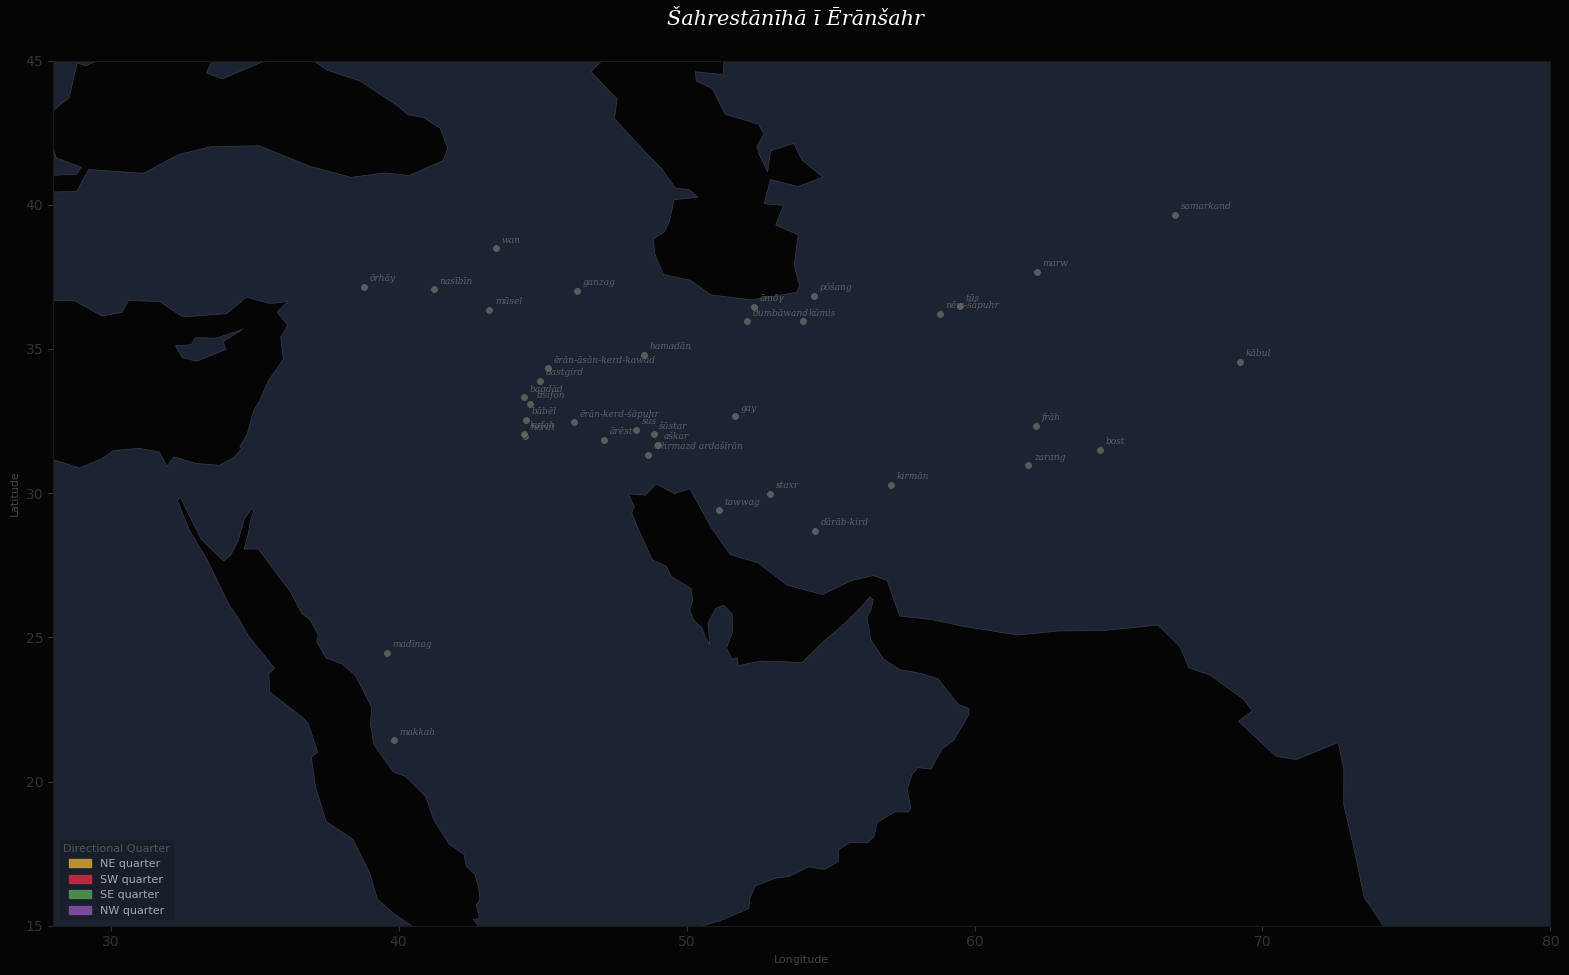

Saved city_map.png


In [75]:
# Colour scheme matching the site / analysis table 
DIR_COLORS = {
    'quarter of the northeast': '#b8922a',
    'quarter of the southwest': '#c02641',
    'quarter of the southeast': '#4a8a4a',
    'quarter of the northwest': '#7a4a9a',
    'unassigned':               '#666666',
}
DIR_LABELS = {
    'quarter of the northeast': 'NE quarter',
    'quarter of the southwest': 'SW quarter',
    'quarter of the southeast': 'SE quarter',
    'quarter of the northwest': 'NW quarter',
    'unassigned':               'unassigned',
}

# Create geometry column
geometry = [Point(row.lon, row.lat) for _, row in df.iterrows()]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# Node size scaled by appearances
gdf['markersize'] = gdf['count'].apply(lambda n: max(30, n * 25))
gdf['color']      = gdf['direction'].map(DIR_COLORS)

# Basemap
from geodatasets import get_path
world = gpd.read_file(get_path('naturalearth.land'))
# Clip to region of interest
minx, miny, maxx, maxy = 28, 15, 80, 45

BG = '#050505'
LAND = '#1c2333'
BORDER = '#3a3a4a'

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Draw land
world.plot(ax=ax, color=LAND, edgecolor=BORDER, linewidth=0.5)

# Clip view
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot cities
for _, row in gdf.iterrows():
    ax.scatter(row.lon, row.lat,
               s=row.markersize,
               color=row.color,
               alpha=0.85,
               zorder=5,
               edgecolors='#1a1a1a',
               linewidths=0.4)
    ax.annotate(row['name'],
                xy=(row.lon, row.lat),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=6.5,
                color=row.color,
                fontstyle='italic',
                fontfamily='serif',
                alpha=0.9,
                zorder=6)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=DIR_LABELS[d])
    for d, c in DIR_COLORS.items() if d != 'unassigned'
]
legend = ax.legend(
    handles=legend_handles,
    loc='lower left',
    framealpha=0.2,
    facecolor='#0d0d0d',
    edgecolor='#2a2a2a',
    labelcolor='#aaaaaa',
    fontsize=8,
    title='Directional Quarter',
    title_fontsize=8
)
legend.get_title().set_color('#555555')

# Titles
ax.tick_params(colors='#333')
for spine in ax.spines.values(): spine.set_edgecolor('#1a1a1a')
ax.set_xlabel('Longitude', color='#444', fontsize=8)
ax.set_ylabel('Latitude',  color='#444', fontsize=8)

fig.text(0.5, 0.97, 'Šahrestānīhā ī Ērānšahr',
         ha='center', va='top', color='#ffffff',
         fontsize=15, fontstyle='italic', fontfamily='serif')
fig.text(0.5, 0.945,
         '',
         ha='center', va='top', color='#555555', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('city_map.png', dpi=180, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved city_map.png')

In [68]:
plt.savefig('city_map.png', dpi=180, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
print('Saved city_map.png')

Saved city_map.png


<Figure size 640x480 with 0 Axes>